# Axis + Copernicus Sentinel-2: segmentação de superfície para apoio a operações de campo

Este notebook desenvolve uma análise de Machine Learning com dados Copernicus/Sentinel-2 de uma região da Nova Zelândia, conectando sensoriamento remoto ao projeto **Axis**.

O Axis é uma aplicação pensada para gerar um **grafo causal de cadeias de eventos** a partir de uma pergunta norteadora. A ideia é que o usuário formule um evento inicial, por exemplo: "a taxa de natalidade do Japão sobe 4x". A partir disso, o aplicativo mostra um grafo em vários níveis, definidos pelo usuário, com consequências prováveis, efeitos secund?rios, impactos em infraestrutura, economia, sociedade e ambiente.

Nesta entrega, a mesma lógica é aplicada ao contexto espacial: uma imagem Sentinel-2 vira uma camada de contexto territorial para alimentar grafos de consequências em cenários de grande evento, como impacto de asteroide, crise climática, tempestade solar ou falha em infraestrutura espacial.

**Pergunta de investigação:** avaliar se, usando apenas bandas espectrais Sentinel-2, é possível segmentar automaticamente a superfície observada e construir um Índice interpretável de risco operacional para apoiar os grafos de consequências do Axis.


## Equipe

| Nome | RM |
|---|---:|
| Diana Letícia de Souza Inocencio | RM553562 |
| João Viktor Carvalho de Souza | RM552613 |
| Victor Augusto Pereira dos Santos | RM553518 |


## 1. Contexto do problema

O enunciado da Global Solution permite usar imagens Copernicus/Sentinel para investigar padrões de cobertura da superfície, uso do solo e fenômenos ambientais. Para manter aderência ao projeto Axis, esta análise trata a imagem como uma camada de inteligência situacional que pode alimentar um grafo causal.

No Axis, a pergunta norteadora gera uma cadeia de consequências. Em um evento espacial extremo, por exemplo, o sistema poderia partir de uma pergunta como: "um objeto próximo da Terra impacta esta região da Nova Zelândia". O grafo então poderia expandir efeitos em níveis: dano inicial, bloqueio de rotas, risco à população, alteração ambiental, resposta logística e impacto econômico.

Neste notebook, o foco não é gerar o grafo completo, mas construir uma camada de dados que ajudaria esse grafo a ser mais realista:

- **Sentinel-2 Level-2A** fornece reflectância de superfície já corrigida atmosfericamente.
- Bandas vis?veis, infravermelho próximo e SWIR permitem calcular Índices como NDVI, NDWI, NDBI e NBR.
- Como não há rótulos manuais no dataset, a abordagem principal será **aprendizado não supervisionado** com K-Means.
- A avaliação será feita por métricas internas de agrupamento e por comparação fraca com a camada SCL, uma classificação de cena fornecida no próprio produto Sentinel-2.

A saída aplicada será um **Índice Axis de risco operacional pós-evento**, pensado como uma variável que poderia virar nós no grafo causal do Axis: áreas úmidas, vegetação, solo exposto, nuvem/neve, incerteza de observação e risco de deslocamento.


## 2. Bibliotecas e configuração

O notebook foi escrito para rodar com bibliotecas comuns de ciência de dados. A leitura dos arquivos `.jp2` usa `Pillow`, porque o ambiente local não tinha `rasterio` instalado inicialmente. Como o `rasterio` foi instalado depois, o projeto também inclui uma seção geoespacial para extrair CRS, resolução e limites reais do raster.


In [1]:
import warnings
from pathlib import Path
from xml.etree import ElementTree as ET

from PIL import Image
Image.MAX_IMAGE_PIXELS = None

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42
LOW_RES_SIZE = (900, 900)
ROOT = Path.cwd()
SAFE_DIR = ROOT / 'S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_20260528T031956.SAFE'
OUT_DIR = ROOT / 'axis_copernicus_outputs'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

SAFE_DIR.exists(), SAFE_DIR.name


(True, 'S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_20260528T031956.SAFE')

## 3. Localização dos arquivos Sentinel-2

O produto `.SAFE` contém v?rias resoluções. Para equilibrar qualidade e tempo de execução, o notebook usa:

| Resolução | Bandas usadas | Função |
|---|---|---|
| 10 m | B02, B03, B04, B08 | azul, verde, vermelho e infravermelho próximo |
| 20 m | B11, B12, SCL | SWIR 1, SWIR 2 e classificação de cena |

Todas as bandas são redimensionadas para uma grade comum de 900 x 900 pixels. Isso reduz o custo computacional sem destruir os padrões principais da cena.


In [2]:
def find_band(safe_dir, pattern):
    matches = list(safe_dir.rglob(pattern))
    if not matches:
        raise FileNotFoundError(f'Arquivo não encontrado: {pattern}')
    return matches[0]

band_paths = {
    'B02_blue_10m': find_band(SAFE_DIR, 'IMG_DATA/R10m/*_B02_10m.jp2'),
    'B03_green_10m': find_band(SAFE_DIR, 'IMG_DATA/R10m/*_B03_10m.jp2'),
    'B04_red_10m': find_band(SAFE_DIR, 'IMG_DATA/R10m/*_B04_10m.jp2'),
    'B08_nir_10m': find_band(SAFE_DIR, 'IMG_DATA/R10m/*_B08_10m.jp2'),
    'B11_swir1_20m': find_band(SAFE_DIR, 'IMG_DATA/R20m/*_B11_20m.jp2'),
    'B12_swir2_20m': find_band(SAFE_DIR, 'IMG_DATA/R20m/*_B12_20m.jp2'),
    'SCL_scene_classification_20m': find_band(SAFE_DIR, 'IMG_DATA/R20m/*_SCL_20m.jp2'),
    'TCI_true_color_10m': find_band(SAFE_DIR, 'IMG_DATA/R10m/*_TCI_10m.jp2'),
}

pd.DataFrame({'arquivo': {k: str(v.relative_to(ROOT)) for k, v in band_paths.items()}})


,arquivo
B02_blue_10m,S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_2...
B03_green_10m,S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_2...
B04_red_10m,S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_2...
B08_nir_10m,S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_2...
B11_swir1_20m,S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_2...
B12_swir2_20m,S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_2...
SCL_scene_classification_20m,S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_2...
TCI_true_color_10m,S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_2...


## 3.1. Metadados geoespaciais com Rasterio

Como o `rasterio` está disponível, também extraímos informações geoespaciais reais de uma banda Sentinel-2: sistema de coordenadas, resolução, dimensões e limites do raster. Isso melhora a reprodutibilidade do projeto e deixa claro que a imagem não é apenas uma matriz de pixels, mas um dado espacial projetado.


In [3]:
import rasterio

with rasterio.open(band_paths['B04_red_10m']) as src:
    rasterio_info = {
        'driver': src.driver,
        'crs': str(src.crs),
        'width_pixels': src.width,
        'height_pixels': src.height,
        'res_x_m': abs(src.transform.a),
        'res_y_m': abs(src.transform.e),
        'bounds_left': src.bounds.left,
        'bounds_bottom': src.bounds.bottom,
        'bounds_right': src.bounds.right,
        'bounds_top': src.bounds.top,
    }

pd.Series(rasterio_info, name='valor').to_frame()


,valor
driver,JP2OpenJPEG
crs,EPSG:32759
width_pixels,10980
height_pixels,10980
res_x_m,10.0
res_y_m,10.0
bounds_left,399960.0
bounds_bottom,4990240.0
bounds_right,509760.0
bounds_top,5100040.0


## 4. Metadados do produto

A data de aquisição e a porcentagem de nuvens ajudam a interpretar os resultados. A presença de nuvens não invalida a análise, mas aumenta a incerteza em parte da cena.


In [4]:
def read_safe_metadata(safe_dir):
    metadata = {'produto': safe_dir.name}
    xml_path = safe_dir / 'MTD_MSIL2A.xml'
    tree = ET.parse(xml_path)
    root = tree.getroot()
    wanted = {
        'PRODUCT_START_TIME',
        'PRODUCT_STOP_TIME',
        'PROCESSING_LEVEL',
        'Cloud_Coverage_Assessment',
        'PRODUCT_URI',
    }
    for elem in root.iter():
        tag = elem.tag.split('}')[-1]
        if tag in wanted and elem.text:
            metadata[tag] = elem.text
    return metadata

metadata = read_safe_metadata(SAFE_DIR)
pd.Series(metadata, name='valor').to_frame()


,valor
produto,S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_2...
PRODUCT_START_TIME,2026-05-27T22:25:41.024Z
PRODUCT_STOP_TIME,2026-05-27T22:25:41.024Z
PRODUCT_URI,S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_2...
PROCESSING_LEVEL,Level-2A
Cloud_Coverage_Assessment,19.582701


## 5. Leitura das bandas e composição visual

As bandas Level-2A são armazenadas em inteiros. Para reflectância aproximada, usamos a escala padrão `DN / 10000`. Em seguida, montamos uma composição RGB para inspeção visual.


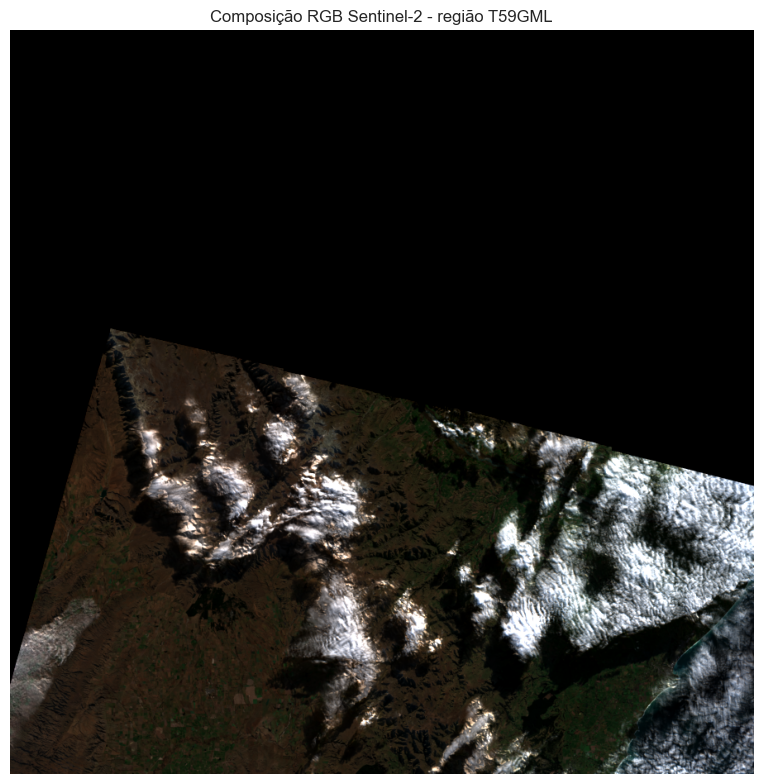

Pixels totais na grade reduzida: 810,000
Pixels válidos usados na análise: 386,931 (47.8%)


In [5]:
def read_jp2(path, size=LOW_RES_SIZE, nearest=False):
    image = Image.open(path)
    resample = Image.Resampling.NEAREST if nearest else Image.Resampling.BILINEAR
    image = image.resize(size, resample=resample)
    return np.array(image)

raw = {
    'blue': read_jp2(band_paths['B02_blue_10m']).astype('float32') / 10000,
    'green': read_jp2(band_paths['B03_green_10m']).astype('float32') / 10000,
    'red': read_jp2(band_paths['B04_red_10m']).astype('float32') / 10000,
    'nir': read_jp2(band_paths['B08_nir_10m']).astype('float32') / 10000,
    'swir1': read_jp2(band_paths['B11_swir1_20m']).astype('float32') / 10000,
    'swir2': read_jp2(band_paths['B12_swir2_20m']).astype('float32') / 10000,
    'scl': read_jp2(band_paths['SCL_scene_classification_20m'], nearest=True).astype('int16'),
}

rgb = np.dstack([raw['red'], raw['green'], raw['blue']])
brightness = np.mean([raw['blue'], raw['green'], raw['red'], raw['nir'], raw['swir1'], raw['swir2']], axis=0)
valid_mask = np.isfinite(rgb).all(axis=-1) & (brightness > 0.001) & (raw['scl'] != 0)

p2, p98 = np.nanpercentile(rgb[valid_mask], [2, 98])
rgb_display = np.clip((rgb - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb_display)
plt.title('Composição RGB Sentinel-2 - região T59GML')
plt.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_rgb.png', dpi=170)
plt.show()

print(f'Pixels totais na grade reduzida: {valid_mask.size:,}')
print(f'Pixels válidos usados na análise: {valid_mask.sum():,} ({valid_mask.mean():.1%})')


## 6. Engenharia de atributos espectrais

Foram criados Índices cl?ssicos de sensoriamento remoto:

| Índice | Fórmula | Interpretação |
|---|---|---|
| NDVI | `(NIR - Red) / (NIR + Red)` | vigor da vegetação |
| NDWI | `(Green - NIR) / (Green + NIR)` | água e umidade superficial |
| NDBI | `(SWIR1 - NIR) / (SWIR1 + NIR)` | solo exposto/construído |
| NBR | `(NIR - SWIR2) / (NIR + SWIR2)` | umidade, vegetação e cicatrizes de queima |


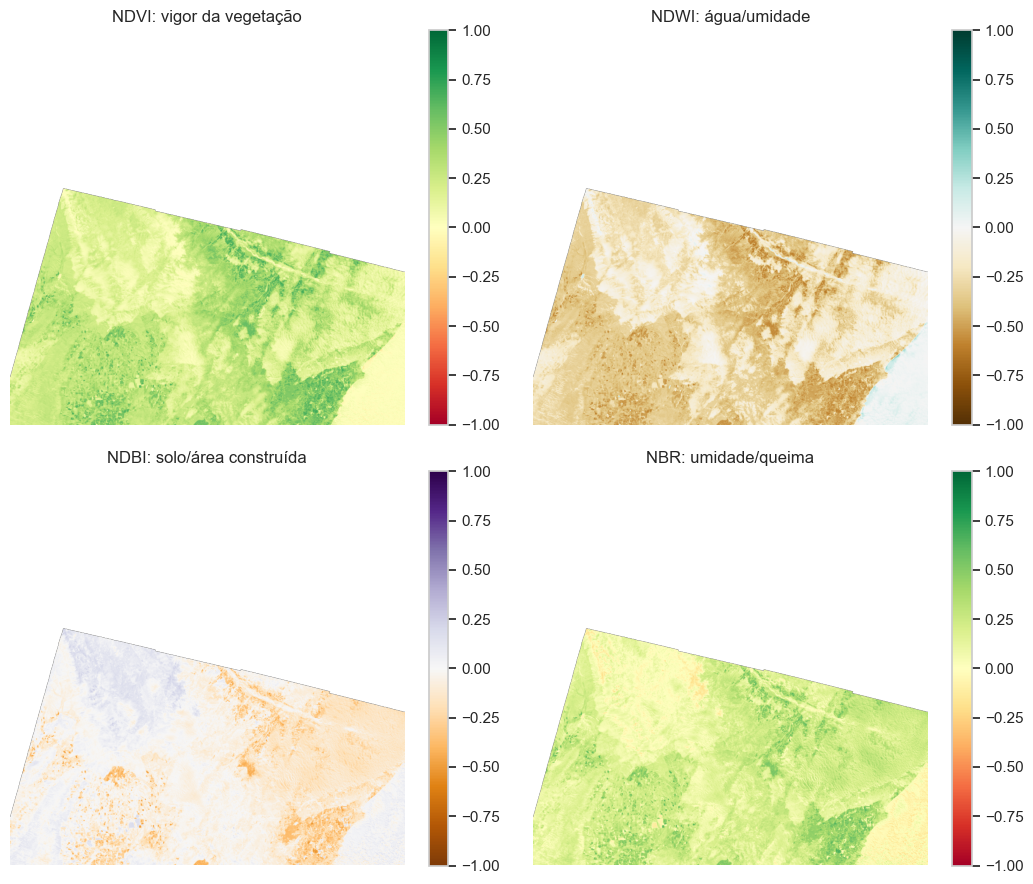

In [6]:
eps = 1e-6
indices = {
    'ndvi': (raw['nir'] - raw['red']) / (raw['nir'] + raw['red'] + eps),
    'ndwi': (raw['green'] - raw['nir']) / (raw['green'] + raw['nir'] + eps),
    'ndbi': (raw['swir1'] - raw['nir']) / (raw['swir1'] + raw['nir'] + eps),
    'nbr': (raw['nir'] - raw['swir2']) / (raw['nir'] + raw['swir2'] + eps),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
plots = [
    ('ndvi', 'NDVI: vigor da vegetação', 'RdYlGn'),
    ('ndwi', 'NDWI: água/umidade', 'BrBG'),
    ('ndbi', 'NDBI: solo/área construída', 'PuOr'),
    ('nbr', 'NBR: umidade/queima', 'RdYlGn'),
]
for ax, (name, title, cmap) in zip(axes.ravel(), plots):
    image = ax.imshow(np.where(valid_mask, indices[name], np.nan), cmap=cmap, vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis('off')
    fig.colorbar(image, ax=ax, fraction=0.045)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_indices_espectrais.png', dpi=170)
plt.show()


## 7. Dataset tabular para Machine Learning

Cada pixel válido vira uma observação. As variáveis combinam bandas originais e Índices derivados. Para treinar com eficiência, sorteamos até 60.000 pixels válidos.


In [7]:
feature_names = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'ndvi', 'ndwi', 'ndbi', 'nbr', 'brightness']
feature_stack = np.stack([
    raw['blue'], raw['green'], raw['red'], raw['nir'], raw['swir1'], raw['swir2'],
    indices['ndvi'], indices['ndwi'], indices['ndbi'], indices['nbr'], brightness,
], axis=-1)

X_all = feature_stack[valid_mask]
scl_all = raw['scl'][valid_mask]

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(X_all.shape[0], size=min(60_000, X_all.shape[0]), replace=False)
X_sample = X_all[sample_idx]
scl_sample = scl_all[sample_idx]

features_df = pd.DataFrame(X_sample, columns=feature_names)
features_df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]


,mean,std,min,25%,50%,75%,max
blue,0.415253,0.292783,0.086800,0.256000,0.283300,0.453425,2.543200
green,0.440835,0.273116,0.098900,0.297100,0.334100,0.473600,2.854100
red,0.451332,0.269480,0.092600,0.294000,0.366600,0.480200,3.278800
nir,0.730705,0.332276,0.134400,0.526800,0.677500,0.875200,3.283900
swir1,0.639456,0.268776,0.134200,0.479500,0.626600,0.737900,3.218700
swir2,0.503611,0.232051,0.115700,0.365000,0.452600,0.575300,3.200200
ndvi,0.242289,0.142855,-0.217900,0.138823,0.236249,0.327002,0.732974
ndwi,-0.255906,0.145786,-0.664969,-0.360073,-0.273725,-0.145575,0.413450
ndbi,-0.057987,0.107883,-0.551326,-0.120648,-0.042843,0.011620,0.282193
nbr,0.174417,0.130774,-0.288022,0.088370,0.174651,0.249502,0.693800


## 8. Seleção do número de clusters

Como não temos rótulos manuais, testamos `k` de 3 a 7. Usamos:

- **Silhouette:** quanto maior, melhor a separação média dos grupos.
- **Davies-Bouldin:** quanto menor, melhor a separação/compactação.
- **Inertia:** soma das distâncias internas, útil como apoio, mas sempre cai quando `k` aumenta.


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

cluster_metrics = []
models = {}
for k in range(3, 8):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)
    cluster_metrics.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels, sample_size=min(10_000, len(labels)), random_state=RANDOM_STATE),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'inertia': model.inertia_,
    })
    models[k] = model

cluster_metrics = pd.DataFrame(cluster_metrics)
best_k = int(cluster_metrics.sort_values(['silhouette', 'davies_bouldin'], ascending=[False, True]).iloc[0]['k'])
best_model = models[best_k]
cluster_metrics


,k,silhouette,davies_bouldin,inertia
0,3,0.331129,0.986770,264726.000000
1,4,0.326612,0.984316,217984.359375
2,5,0.347435,0.960888,172481.000000
3,6,0.348853,0.965023,148335.609375
4,7,0.341814,1.016229,134905.000000


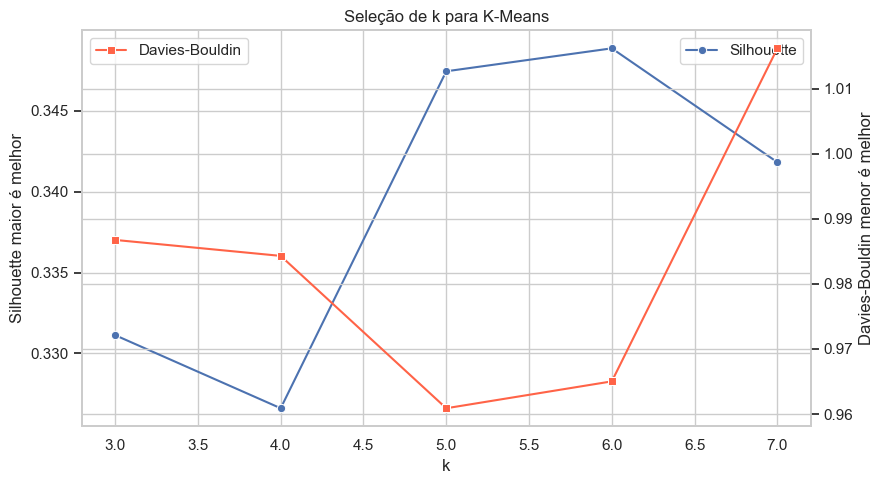

Melhor k escolhido automaticamente: 6


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=cluster_metrics, x='k', y='silhouette', marker='o', label='Silhouette', ax=ax)
ax2 = ax.twinx()
sns.lineplot(data=cluster_metrics, x='k', y='davies_bouldin', marker='s', color='tomato', label='Davies-Bouldin', ax=ax2)
ax.set_title('Seleção de k para K-Means')
ax.set_ylabel('Silhouette maior é melhor')
ax2.set_ylabel('Davies-Bouldin menor é melhor')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_metricas_kmeans.png', dpi=170)
plt.show()

print(f'Melhor k escolhido automaticamente: {best_k}')


## 9. Mapa de clusters e interpretação semântica

Depois de escolher `k`, o modelo é aplicado a todos os pixels válidos da grade reduzida. Cada cluster é interpretado por médias de NDVI, NDWI, NDBI, NBR, brilho e pela classe SCL mais frequente.


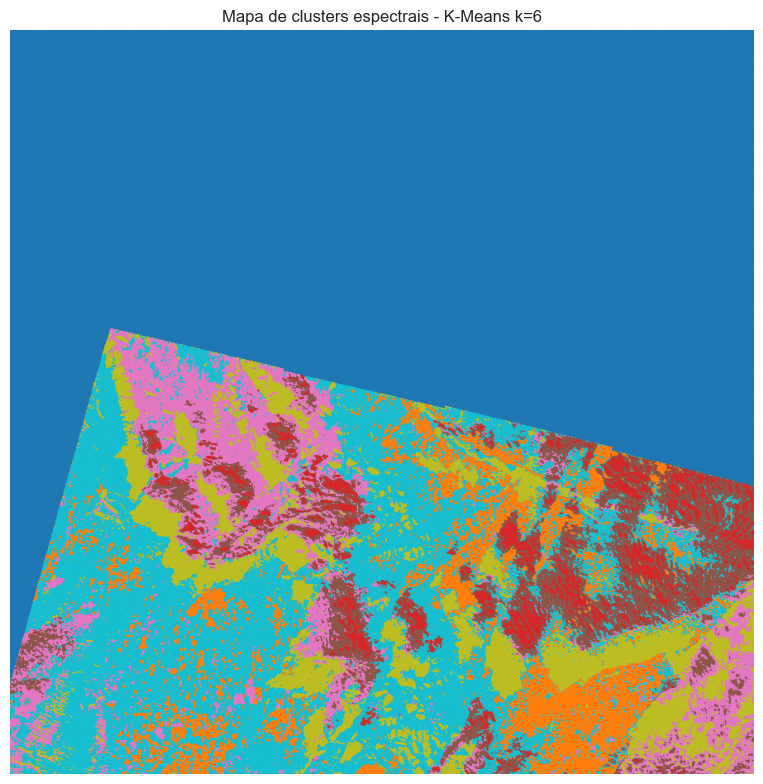

In [12]:
labels_sample = best_model.predict(X_scaled)
flat_features = feature_stack.reshape(-1, feature_stack.shape[-1])
valid_flat = valid_mask.reshape(-1)
valid_positions = np.where(valid_flat)[0]

label_flat = np.full(valid_flat.shape, -1, dtype='int16')
for start in range(0, len(valid_positions), 100_000):
    positions = valid_positions[start:start + 100_000]
    label_flat[positions] = best_model.predict(scaler.transform(flat_features[positions]))
label_map = label_flat.reshape(valid_mask.shape)

plt.figure(figsize=(8, 8))
plt.imshow(label_map, cmap='tab10')
plt.title(f'Mapa de clusters espectrais - K-Means k={best_k}')
plt.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_mapa_clusters.png', dpi=170)
plt.show()


In [13]:
def cluster_profiles(label_map):
    rows = []
    for cluster in range(best_k):
        mask = label_map == cluster
        row = {
            'cluster': cluster,
            'pixels': int(mask.sum()),
            'percent': float(mask.sum() / valid_mask.sum() * 100),
        }
        for name, matrix in {
            'ndvi': indices['ndvi'],
            'ndwi': indices['ndwi'],
            'ndbi': indices['ndbi'],
            'nbr': indices['nbr'],
            'brightness': brightness,
            'nir': raw['nir'],
            'swir1': raw['swir1'],
        }.items():
            row[f'{name}_mean'] = float(np.nanmean(matrix[mask])) if mask.any() else np.nan
        values, counts = np.unique(raw['scl'][mask], return_counts=True) if mask.any() else ([], [])
        row['scl_mode'] = int(values[counts.argmax()]) if len(values) else -1
        rows.append(row)
    return pd.DataFrame(rows)

def interpret_cluster(row):
    if row.ndwi_mean > 0.10 or row.scl_mode == 6:
        return 'agua/superficie umida'
    if row.ndvi_mean > 0.42:
        return 'vegetacao densa'
    if row.ndvi_mean > 0.22:
        return 'vegetacao rala/campo'
    if row.scl_mode in [8, 9, 10, 11] or row.brightness_mean > 0.45:
        return 'nuvem/neve/brilho alto'
    if row.ndbi_mean > -0.02 and row.swir1_mean > 0.16:
        return 'solo exposto/area construida'
    return 'sombra/rocha/solo escuro'

profiles = cluster_profiles(label_map)
profiles['classe_interpretada'] = profiles.apply(interpret_cluster, axis=1)
profiles


,cluster,pixels,percent,ndvi_mean,ndwi_mean,ndbi_mean,nbr_mean,brightness_mean,nir_mean,swir1_mean,scl_mode,classe_interpretada
0,0,48460,12.524197,0.493147,-0.463999,-0.244886,0.399792,0.442222,0.878581,0.533359,4,vegetacao densa
1,1,19077,4.930336,0.108955,-0.110841,-0.095017,0.182402,1.328114,1.610836,1.342393,9,nuvem/neve/brilho alto
2,2,49566,12.810036,0.151973,-0.147559,-0.087440,0.162694,0.859603,1.077992,0.905738,9,nuvem/neve/brilho alto
3,3,57742,14.923074,0.128356,-0.157598,0.059114,0.021974,0.527933,0.599491,0.674148,5,nuvem/neve/brilho alto
4,4,64118,16.570913,0.131851,-0.124259,-0.016919,0.075635,0.278757,0.326605,0.316933,3,solo exposto/area construida
5,5,147968,38.241444,0.301635,-0.340161,-0.045357,0.206075,0.454577,0.678666,0.621151,5,vegetacao rala/campo


## 10. Avaliação com a camada SCL como referência fraca

A camada SCL não é um gabarito humano perfeito, mas é útil como referência aproximada. Reagrupamos os códigos SCL em classes amplas e medimos a concordância com os clusters usando ARI e NMI.

Interpretação importante: como K-Means aprende somente padrões espectrais, a concordância não precisa ser perfeita. Um ARI/NMI moderado indica que parte da estrutura física capturada pelo Sentinel aparece nos clusters, mas também há mistura causada por sombra, relevo, nuvens, neve e transições naturais da superfície.


In [14]:
scl_group = np.full(raw['scl'].shape, -1, dtype='int16')
for codes, group_id in [
    ([6], 0),              # água
    ([4], 1),              # vegetação
    ([5], 2),              # solo exposto
    ([8, 9, 10, 11], 3),   # nuvem/cirrus/neve
    ([2, 3], 4),           # sombra/escuro
    ([7], 5),              # não classificado
]:
    for code in codes:
        scl_group[raw['scl'] == code] = group_id

eval_mask = valid_mask & (scl_group >= 0) & (label_map >= 0)
ari = adjusted_rand_score(scl_group[eval_mask].ravel(), label_map[eval_mask].ravel())
nmi = normalized_mutual_info_score(scl_group[eval_mask].ravel(), label_map[eval_mask].ravel())

pd.DataFrame({
    'métrica': ['Adjusted Rand Index vs SCL', 'Normalized Mutual Information vs SCL'],
    'valor': [ari, nmi],
})


,métrica,valor
0,Adjusted Rand Index vs SCL,0.243368
1,Normalized Mutual Information vs SCL,0.359720


## 11. Modelo interpretável auxiliar: Random Forest

Para explicar quais variáveis sustentam os clusters, treinamos um Random Forest para reproduzir os rótulos do K-Means. Esse modelo não cria o agrupamento; ele funciona como um **surrogate model** interpretável.

Se a acurácia for alta, significa que os clusters são previsíveis a partir das variáveis espectrais e não são apenas ruído.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, labels_sample,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=labels_sample,
)

rf = RandomForestClassifier(
    n_estimators=140,
    max_depth=12,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_accuracy = rf.score(X_test, y_test)

importance = pd.DataFrame({
    'variavel': feature_names,
    'importancia': rf.feature_importances_,
}).sort_values('importancia', ascending=False)

print(f'Acuracia do Random Forest surrogate: {rf_accuracy:.4f}')
importance


Acuracia do Random Forest surrogate: 0.9902


,variavel,importancia
10,brightness,0.209459
9,nbr,0.137105
6,ndvi,0.105864
3,nir,0.104940
2,red,0.102596
1,green,0.085007
7,ndwi,0.074670
8,ndbi,0.051016
5,swir2,0.046757
4,swir1,0.042698


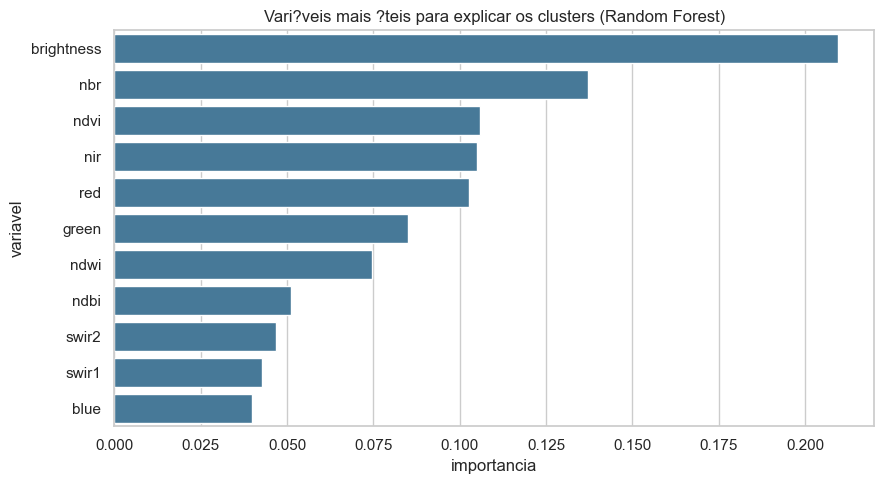

In [16]:
plt.figure(figsize=(9, 5))
sns.barplot(data=importance, y='variavel', x='importancia', color='#3A7CA5')
plt.title('Vari?veis mais ?teis para explicar os clusters (Random Forest)')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_importancia_rf.png', dpi=170)
plt.show()


## 12. Visualização dos pixels com PCA

A redução para duas componentes principais permite observar se os pixels formam grupos relativamente separados no espaço espectral.


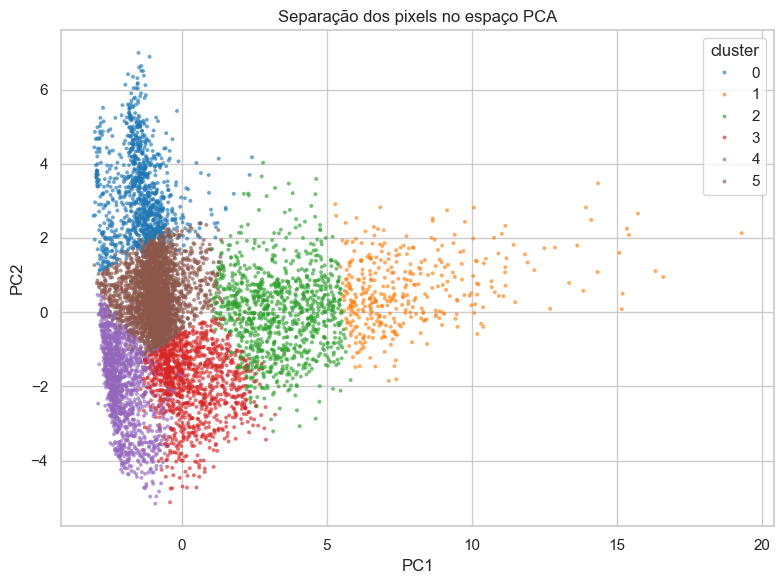

Variância explicada pelas duas primeiras componentes: [0.594 0.309]


In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame({'PC1': components[:, 0], 'PC2': components[:, 1], 'cluster': labels_sample})
plot_sample = pca_df.sample(min(8000, len(pca_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_sample, x='PC1', y='PC2', hue='cluster', palette='tab10', s=8, linewidth=0, alpha=0.65)
plt.title('Separação dos pixels no espaço PCA')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_pca_clusters.png', dpi=170)
plt.show()

print('Variância explicada pelas duas primeiras componentes:', pca.explained_variance_ratio_.round(3))


## 13. Índice Axis de risco operacional pós-evento

O Índice abaixo é uma proposta aplicada ao Axis. Ele transforma a classe interpretada de cada cluster em um peso simples que poderia alimentar o grafo causal como um fator de consequência territorial.

| Classe interpretada | Peso | Justificativa |
|---|---:|---|
| vegetação densa | 0,30 | menor exposição direta, mas pode dificultar deslocamento |
| vegetação rala/campo | 0,35 | melhor visibilidade e deslocamento relativo |
| sombra/rocha/solo escuro | 0,50 | incerteza espectral e possível relevo/sombra |
| solo exposto/área construída | 0,55 | possível infraestrutura, solo inst?vel ou área antropizada |
| nuvem/neve/brilho alto | 0,80 | alta incerteza de observação e risco de interpretação |
| água/superfície ?mida | 0,90 | deslocamento difícil e risco de inundação/isolamento |

O objetivo não é substituir validação de campo. É criar uma camada inicial, local e explicável para priorização de atenção. Em um grafo do Axis, esses pesos poderiam alterar a cadeia de consequências: maior dificuldade de acesso, maior risco para equipes, maior incerteza de mapeamento ou necessidade de reconhecimento adicional.


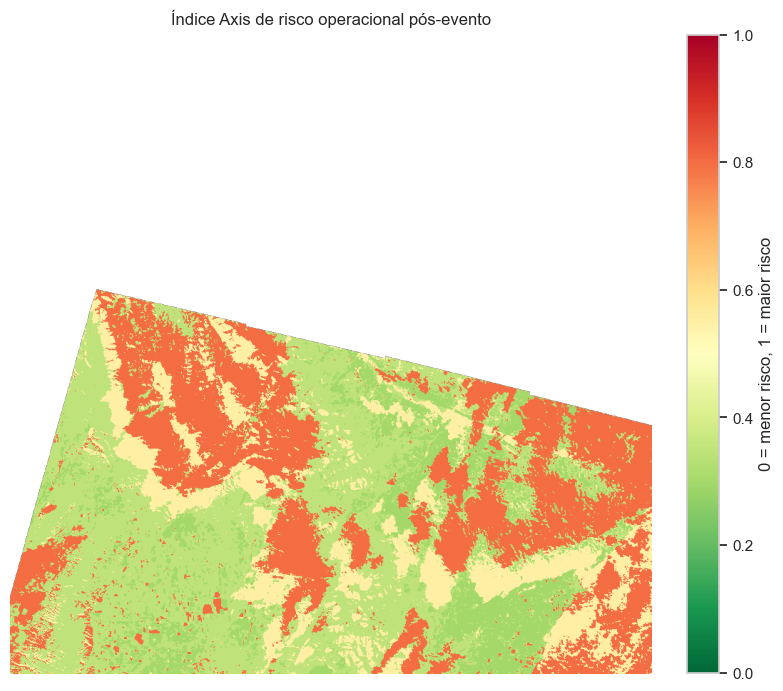

,cluster,percent,classe_interpretada,risco_operacional_axis
0,0,12.524197,vegetacao densa,0.30
1,1,4.930336,nuvem/neve/brilho alto,0.80
2,2,12.810036,nuvem/neve/brilho alto,0.80
3,3,14.923074,nuvem/neve/brilho alto,0.80
4,4,16.570913,solo exposto/area construida,0.55
5,5,38.241444,vegetacao rala/campo,0.35


In [18]:
risk_weights = {
    'vegetacao densa': 0.30,
    'vegetacao rala/campo': 0.35,
    'sombra/rocha/solo escuro': 0.50,
    'solo exposto/area construida': 0.55,
    'nuvem/neve/brilho alto': 0.80,
    'agua/superficie umida': 0.90,
}
profiles['risco_operacional_axis'] = profiles['classe_interpretada'].map(risk_weights)

risk_map = np.full(label_map.shape, np.nan)
for _, row in profiles.iterrows():
    risk_map[label_map == row.cluster] = row.risco_operacional_axis

plt.figure(figsize=(8, 8))
image = plt.imshow(risk_map, cmap='RdYlGn_r', vmin=0, vmax=1)
plt.title('Índice Axis de risco operacional pós-evento')
plt.axis('off')
plt.colorbar(image, fraction=0.045, label='0 = menor risco, 1 = maior risco')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_mapa_risco_axis.png', dpi=170)
plt.show()

profiles[['cluster', 'percent', 'classe_interpretada', 'risco_operacional_axis']].sort_values('cluster')


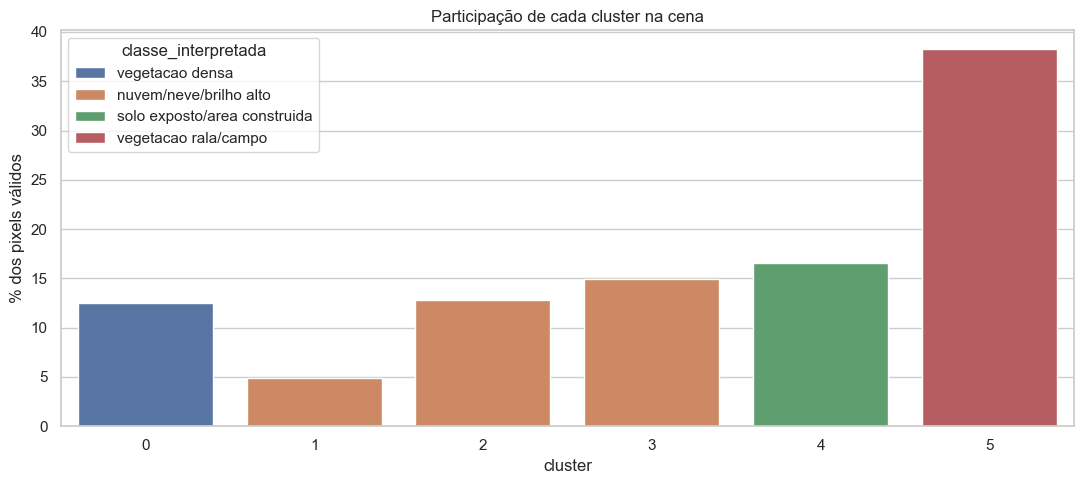

In [19]:
plt.figure(figsize=(11, 5))
sns.barplot(data=profiles.sort_values('cluster'), x='cluster', y='percent', hue='classe_interpretada')
plt.title('Participação de cada cluster na cena')
plt.ylabel('% dos pixels válidos')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_participacao_clusters.png', dpi=170)
plt.show()


## 14. Consolidação dos resultados

A tabela final resume as decisões e métricas principais.


In [20]:
summary = pd.DataFrame({
    'item': [
        'Produto Sentinel-2',
        'Nível de processamento',
        'Data de aquisição',
        'Cobertura de nuvens no metadado',
        'Pixels válidos na grade reduzida',
        'Melhor k no K-Means',
        'Silhouette do melhor k',
        'Davies-Bouldin do melhor k',
        'ARI contra SCL agrupado',
        'NMI contra SCL agrupado',
        'Acurácia do Random Forest surrogate',
    ],
    'valor': [
        metadata.get('produto'),
        metadata.get('PROCESSING_LEVEL'),
        metadata.get('PRODUCT_START_TIME'),
        metadata.get('Cloud_Coverage_Assessment'),
        int(valid_mask.sum()),
        best_k,
        float(cluster_metrics.loc[cluster_metrics.k == best_k, 'silhouette'].iloc[0]),
        float(cluster_metrics.loc[cluster_metrics.k == best_k, 'davies_bouldin'].iloc[0]),
        float(ari),
        float(nmi),
        float(rf_accuracy),
    ],
})
summary


,item,valor
0,Produto Sentinel-2,S2C_MSIL2A_20260527T222541_N0512_R029_T59GML_2...
1,Nível de processamento,Level-2A
2,Data de aquisição,2026-05-27T22:25:41.024Z
3,Cobertura de nuvens no metadado,19.582701
4,Pixels válidos na grade reduzida,386931
5,Melhor k no K-Means,6
6,Silhouette do melhor k,0.348853
7,Davies-Bouldin do melhor k,0.965023
8,ARI contra SCL agrupado,0.243368
9,NMI contra SCL agrupado,0.35972


In [21]:
cluster_metrics.to_csv(OUT_DIR / 'metricas_kmeans.csv', index=False)
profiles.to_csv(OUT_DIR / 'perfis_clusters.csv', index=False)
importance.to_csv(OUT_DIR / 'importancia_random_forest.csv', index=False)
summary.to_csv(OUT_DIR / 'resumo_resultados.csv', index=False)
np.savez_compressed(
    OUT_DIR / 'mapas_baixa_resolucao.npz',
    label_map=label_map,
    risk_map=risk_map,
    ndvi=indices['ndvi'],
    ndwi=indices['ndwi'],
    ndbi=indices['ndbi'],
    nbr=indices['nbr'],
    valid_mask=valid_mask,
)

print('Arquivos gerados em:', OUT_DIR)
for path in sorted(OUT_DIR.rglob('*')):
    if path.is_file():
        print('-', path.relative_to(ROOT))


Arquivos gerados em: C:\Users\vikto\OneDrive\Área de Trabalho\GS - Machine Learning\axis_copernicus_outputs
- axis_copernicus_outputs\figures\01_rgb.png
- axis_copernicus_outputs\figures\02_indices_espectrais.png
- axis_copernicus_outputs\figures\03_metricas_kmeans.png
- axis_copernicus_outputs\figures\04_mapa_clusters.png
- axis_copernicus_outputs\figures\05_mapa_risco_axis.png
- axis_copernicus_outputs\figures\06_participacao_clusters.png
- axis_copernicus_outputs\figures\07_importancia_rf.png
- axis_copernicus_outputs\figures\08_pca_clusters.png
- axis_copernicus_outputs\importancia_random_forest.csv
- axis_copernicus_outputs\mapas_baixa_resolucao.npz
- axis_copernicus_outputs\metricas_avaliacao.csv
- axis_copernicus_outputs\metricas_kmeans.csv
- axis_copernicus_outputs\perfis_clusters.csv
- axis_copernicus_outputs\resumo_execucao.json
- axis_copernicus_outputs\resumo_resultados.csv


## 15. Discussão crítica

A análise mostra que os dados Sentinel-2 permitem construir uma leitura útil da superfície mesmo sem rótulos manuais. O melhor agrupamento encontrado foi `k=6`, com clusters espectrais que se conectam a classes interpretáveis como vegetação densa, vegetação rala/campo, solo exposto/área construída e regiões de brilho alto associadas a nuvem/neve/incerteza.

O Random Forest surrogate obteve acurácia alta ao reproduzir os clusters. Isso indica que os grupos não são aleatérios: eles são explicáveis por variáveis físicas, principalmente brilho, NBR, NDVI, NIR e banda vermelha. A comparação com SCL apresentou concordância moderada, o que é esperado porque a SCL é uma referência fraca e porque K-Means separa padrões espectrais, não categorias humanas finais.

Para o Axis, o principal valor está na camada derivada de risco operacional. Como o aplicativo gera grafos de consequências a partir de uma pergunta inicial, uma camada territorial obtida por satélite pode tornar a cadeia mais concreta. Por exemplo, se o evento inicial for um impacto, uma enchente secundária ou uma falha de infraestrutura espacial, o grafo pode incorporar nós relacionados a deslocamento, acesso, visibilidade, isolamento, água superficial e incerteza ambiental.


## 16. Limitações e próximos passos

**Limitações:**

- O estudo usa uma única cena Sentinel-2, então não mede mudança temporal.
- A leitura foi feita em baixa resolução para viabilizar execução em notebook comum.
- K-Means não entende contexto espacial; pixels vizinhos podem ser classificados sem suavização.
- A interpretação semântica dos clusters é heurística, baseada em Índices e SCL.
- A camada SCL é usada como referência fraca, não como verdade absoluta.

**Próximos passos recomendados:**

- Comparar cenas antes/depois de um evento real usando delta NDVI, delta NBR e delta NDWI.
- Usar `rasterio` para preservar georreferenciamento e exportar GeoTIFF do Índice Axis.
- Conectar a saída deste notebook ao motor de grafo do Axis, criando nós de consequência territorial.
- Testar segmentação com MiniBatchKMeans, Gaussian Mixture, DBSCAN ou uma CNN/autoencoder se houver mais imagens.
- Validar o Índice com áreas conhecidas de água, neve, vegetação e uso urbano.


## 17. Conclusão

A pergunta central foi respondida positivamente: é possível usar bandas Sentinel-2 para segmentar automaticamente a superfície e gerar um Índice operacional interpretável para o Axis. A solução é coerente com a indústria espacial porque transforma dados abertos de observação da Terra em uma camada de decisão aplicada a risco, resposta em campo e construção de grafos causais.

O trabalho cumpre a proposta da Global Solution ao escolher o dataset Copernicus/Sentinel, contextualizar as variáveis, realizar análise exploratéria, aplicar Machine Learning, avaliar os resultados e interpretar os achados para além de métricas numéricas.
